![logo](../../../LogoLine_horizon_C3S.png)

<div class="alert alert-block alert-warning">
Please note that this repository is used for development and review, so quality assessments should be considered work in progress until they are merged into the main branch
</div>

# Root zone soil moisture during Australia’s Tinderbox Drought

Production date: 27-04-2026

Produced by: Amaya Camila Trigoso Barrientos (VUB)

## 🌍 Use case: Detecting the 2017-2019 drought in south-east Australia.

## ❓ Quality assessment question(s)
**How well does the satellite derived C3S root zone soil moisture dataset detect the negative anomalies occurred during the drought of 2017-2019 in south-east Australia?**

The 2017–2019 “Tinderbox Drought” in south-eastern Australia was characterized by persistent precipitation deficits during the cool season (April–September), leading to prolonged soil moisture deficits and increased environmental stress [[1]](https://doi.org/10.1126/sciadv.adj3460). This event provides a suitable case study to evaluate the ability of the Copernicus Climate Change Service (C3S) soil moisture dataset to detect drought extremes in a time series context.

In this notebook, the root zone soil moisture variable (rzsm_1m) is analysed to assess whether the dataset can capture the temporal persistence, spatial extent, and severity of drought conditions associated with this event. The analysis is framed within the extremes-detection quality category, focusing on the dataset’s suitability to identify sustained negative anomalies and their spatial patterns.

## 📢 Quality assessment statement

```{admonition} These are the key outcomes of this assessment
:class: note
* The C3S root zone soil moisture dataset captures the multi-year persistence of negative soil moisture anomalies during the 2017–2019 cool seasons.
* The dataset represents the spatial extent and temporal expansion of drought conditions across the Murray–Darling Basin.
* The dataset reproduces a spatial pattern broadly consistent with the drought-affected region identified in Devanand et al. (2024) [[1]](https://doi.org/10.1126/sciadv.adj3460).
* The delineation of the core drought-affected area is sensitive to the percentile threshold, with lower thresholds providing clearer identification of the most severe conditions.

```

## 📋 Methodology

Standardized root zone soil moisture anomalies (SRZSMA) were computed using a baseline period of 1980–2016, following a month-wise standardization approach to account for seasonal variability. The analysis focuses on the cool-season months (April–September) during the period 2017–2019, consistent with the definition of the Tinderbox Drought in Devanand et al. (2024) [[1]](https://doi.org/10.1126/sciadv.adj3460).

Multiple complementary indicators were used to assess drought conditions. Basin-mean SRZSMA was calculated to evaluate the temporal evolution of drought intensity (in Murray-Darling Basin). The spatial extent of drought was quantified as the fraction of basin area below fixed SRZSMA thresholds (−1, −1.5, −2), providing information on how widespread the anomalies were.

In addition, a percentile-based drought frequency analysis was performed using root zone soil moisture. Calendar-month-specific percentile thresholds (e.g. P15) were derived from the baseline period and used to compute the fraction of time each grid cell experienced low soil moisture conditions during the analysis period. This approach allows comparison with Devanand et al. (2024) [[1]](https://doi.org/10.1126/sciadv.adj3460), who use a similar fraction-of-time framework based on multiple drought indicators.

Differences in spatial patterns between datasets were explored by testing alternative percentile thresholds (e.g. P07), allowing assessment of the sensitivity of drought detection to the definition of extreme conditions.

**[](satellite_satellite-soil-moisture_extremes-detection_q01:section-1)**

**[](satellite_satellite-soil-moisture_extremes-detection_q01:section-2)**

**[](satellite_satellite-soil-moisture_extremes-detection_q01:section-3)**
 
**[](satellite_satellite-soil-moisture_extremes-detection_q01:section-4)**
 
**[](satellite_satellite-soil-moisture_extremes-detection_q01:section-5)**

## 📈 Analysis and results

(satellite_satellite-soil-moisture_extremes-detection_q01:section-1)=
### 1. Download and preprocess data

#### Import packages

In [2]:
import xarray as xr
import numpy as np
import fsspec
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import shapely.geometry
from shapely.geometry import Point
from shapely.geometry import MultiPolygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from c3s_eqc_automatic_quality_control import diagnostics, download, plot, utils
from matplotlib import animation, pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import path
import matplotlib.dates as mdates
import rioxarray as rxr
import requests
import zipfile
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import calendar
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import BoundaryNorm

plt.style.use("seaborn-v0_8-notebook")

In [3]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

#### Set the data request

In [74]:
collection_id = "satellite-soil-moisture"
request = {
    "variable": ["root_zone_soil_moisture_volumetric"],
    "time_aggregation": ["month_average"],
    "year": [
        "1980", "1981", "1982",
        "1983", "1984", "1985",
        "1986", "1987", "1988",
        "1989", "1990", "1991",
        "1992", "1993", "1994",
        "1995", "1996", "1997",
        "1998", "1999", "2000",
        "2001", "2002", "2003",
        "2004", "2005", "2006",
        "2007", "2008", "2009",
        "2010", "2011", "2012",
        "2013", "2014", "2015",
        "2016", "2017", "2018",
        "2019"
    ],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "day": ["01"],
    "type_of_record": ["cdr"],
    "version": ["v202505"]
}

#### Download data

In [75]:
# Dataset
ds = download.download_and_transform(
    collection_id,
    request,
    chunks={"year": 1},
    transform_chunks=False,
)

100%|██████████| 40/40 [00:00<00:00, 64.19it/s]


#### Load shapefiles

The Murray–Darling Basin boundary was acces from the Murray–Darling Basin Authority dataset [[2]](https://data.gov.au/data/dataset/4ede9aed-5620-47db-a72b-0b3aa0a3ced0/resource/8a6d889d-723b-492d-8c12-b8b0d1ba4b5a).

In [6]:
#Load Murray Darling Basin Boundary
url_mdb = "zip+https://data.gov.au/data/dataset/4ede9aed-5620-47db-a72b-0b3aa0a3ced0/resource/8a6d889d-723b-492d-8c12-b8b0d1ba4b5a/download/mdb_boundary.zip!mdb_boundary.shp"

mdb_gdf = gpd.read_file(url_mdb).to_crs("EPSG:4326")

The shapefile for Australia was accessed from the GADM Database of Global Administrative Areas (version 4.1) via the UC Davis GeoData repository [[3]](https://gadm.org/download_country.html).

In [7]:
# Shapefile of Australia
url = "zip+https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_AUS_shp.zip!gadm41_AUS_0.shp"
aus = gpd.read_file(url).to_crs("EPSG:4326")

####  Subset data to Australia

The variable rzsm_1m (root zone soil moisture) from the C3S soil moisture v202505 dataset was selected. This variable represents a weighted average of the first three soil layers, with weights proportional to layer thickness, resulting in a stronger contribution from deeper layers. Values are expressed in m³ m⁻³ (see [PUGS](https://confluence.ecmwf.int/pages/viewpage.action?pageId=514318069)).

The root zone soil moisture dataset was prepared by assigning a geographic coordinate reference system (EPSG:4326) and defining the spatial dimensions. It was then clipped to the Australian land boundary to restrict the analysis domain.

In [8]:
def prepare_sm_for_clip(da):
    """
    Prepare soil moisture DataArray for rioxarray clipping.
    """
    da = da.rio.write_crs("EPSG:4326", inplace=False)
    da = da.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=False)
    return da


def clip_da_to_gdf(da, gdf, drop=True):
    """
    Clip DataArray to GeoDataFrame geometry.
    drop=True crops to the polygon extent.
    """
    return da.rio.clip(
        gdf.geometry,
        gdf.crs,
        drop=drop,
        all_touched=True,
    )

In [76]:
sm = ds["rzsm_1m"]
sm = prepare_sm_for_clip(sm)
sm_aus = clip_da_to_gdf(sm, aus, drop=True)

(satellite_satellite-soil-moisture_extremes-detection_q01:section-2)=
### 2. SRZSMA computation

Standardized Root Zone Soil Moisture Anomalies (SRZSMA) were computed following a similar approach to that used by the European Drought Observatory (EDO) [[4]](https://drought.emergency.copernicus.eu/data/factsheets/factsheet_soilmoisture.pdf). Monthly root zone soil moisture values for each grid cell were compared against a climatological reference period (1980–2016). The anomaly was calculated by subtracting the climatological mean of the corresponding calendar month and normalizing by the associated standard deviation:
$$
\text{SRZSMA} = \frac{\text{RZSM}_t - \overline{\text{RZSM}}}{\sigma_{\text{RZSM}}}
$$
where:

- $\text{RZSM}_t$ is the root zone soil moisture at time $t$ for a given grid cell  
- $\overline{\text{RZSM}}$ is the mean root zone soil moisture for the same calendar month over the baseline period (1980–2016)  
- $\sigma_{\text{RZSM}}$ is the standard deviation of root zone soil moisture for the same calendar month over the baseline period

The transformation was applied to the full 1980–2019 time series over the Australian domain to ensure consistency across subsequent analyses.

In [90]:
def compute_srzsma(da, target_start,target_end,
                 baseline_start, baseline_end):
    baseline = da.sel(time=slice(baseline_start, baseline_end))
    target = da.sel(time=slice(target_start, target_end))

    monthly_ssma = []

    for t in target.time:
        month = int(t.dt.month)

        target_t = target.sel(time=t)

        baseline_month = baseline.where(baseline["time.month"] == month, drop=True)
        clim_mean = baseline_month.mean(dim="time")
        clim_std = baseline_month.std(dim="time")

        # keep only pixels where std is positive and finite
        clim_std = clim_std.where((clim_std > 0) & np.isfinite(clim_std))

        ssma_t = (target_t - clim_mean) / clim_std

        # remove inf / -inf / invalid values created during division
        ssma_t = ssma_t.where(np.isfinite(ssma_t))

        ssma_t = ssma_t.expand_dims(time=[t.values])
        monthly_ssma.append(ssma_t)

    ssma = xr.concat(monthly_ssma, dim="time")
    ssma.name = "SRZSMA"

    if "month" in ssma.coords and "month" not in ssma.dims:
        ssma = ssma.drop_vars("month")

    return ssma

In [91]:
ssma_aus = compute_ssma(
    sm_aus,
    target_start="1980-01-01",
    target_end="2019-12-31",
    baseline_start="1980-01-01",
    baseline_end="2016-12-31",
)

(satellite_satellite-soil-moisture_extremes-detection_q01:section-3)=
### 3. Basin-averaged SRZSMA time series

Figure 1 from Devanand et al. (2024) [[1]](https://doi.org/10.1126/sciadv.adj3460) is used as a reference to contextualize the spatial extent of the 2017–2019 “Tinderbox Drought” in south-east Australia. In that study, the drought area is defined based on sustained precipitation deficits during the cool season (April–September) over three consecutive years (2017–2019).

As an explicit spatial delineation of the drought-affected region was not available, the Murray–Darling Basin is used here as a proxy for the drought area. This choice is supported by the strong spatial correspondence between the basin extent and the region identified as affected by the drought in Figure 1 of Devanand et al. (2024).

![image.png](d82cae1c-d0fa-4e7a-8324-09bed6de01ac.png)

*Figure 1. The drought focus region. The thick blue line shows the outline of the region in drought during 2017–2019. Basemap colors denote elevation. The map also shows agricultural areas, the Murray Darling Basin (MDB, thin aqua line), smaller river basins, locations of streamflow stations, and borewells. Source: Devanand et al. (2024) [[1]](https://doi.org/10.1126/sciadv.adj3460)*

The subsequent analysis evaluates how these prolonged precipitation deficits are reflected in surface soil moisture conditions, using SRZSMA aggregated over the basin.

The SRZSMA field was clipped to the Murray–Darling Basin and restricted to the 2017–2019 period. A spatially weighted basin mean was then calculated to summarize the temporal evolution of drought conditions over the study area.

In [92]:
# Clip SSMA to the Murray–Darling Basin
ssma_mdb = clip_da_to_gdf(ssma_aus, mdb_gdf, drop=True)

# Select only the 2017–2019 period
ssma_mdb_2017_2019 = ssma_mdb.sel(time=slice("2017-01-01", "2019-12-31"))

# Compute basin spatial mean using the diagnostics helper
ssma_spatial_mean = diagnostics.spatial_weighted_mean(ssma_mdb_2017_2019)

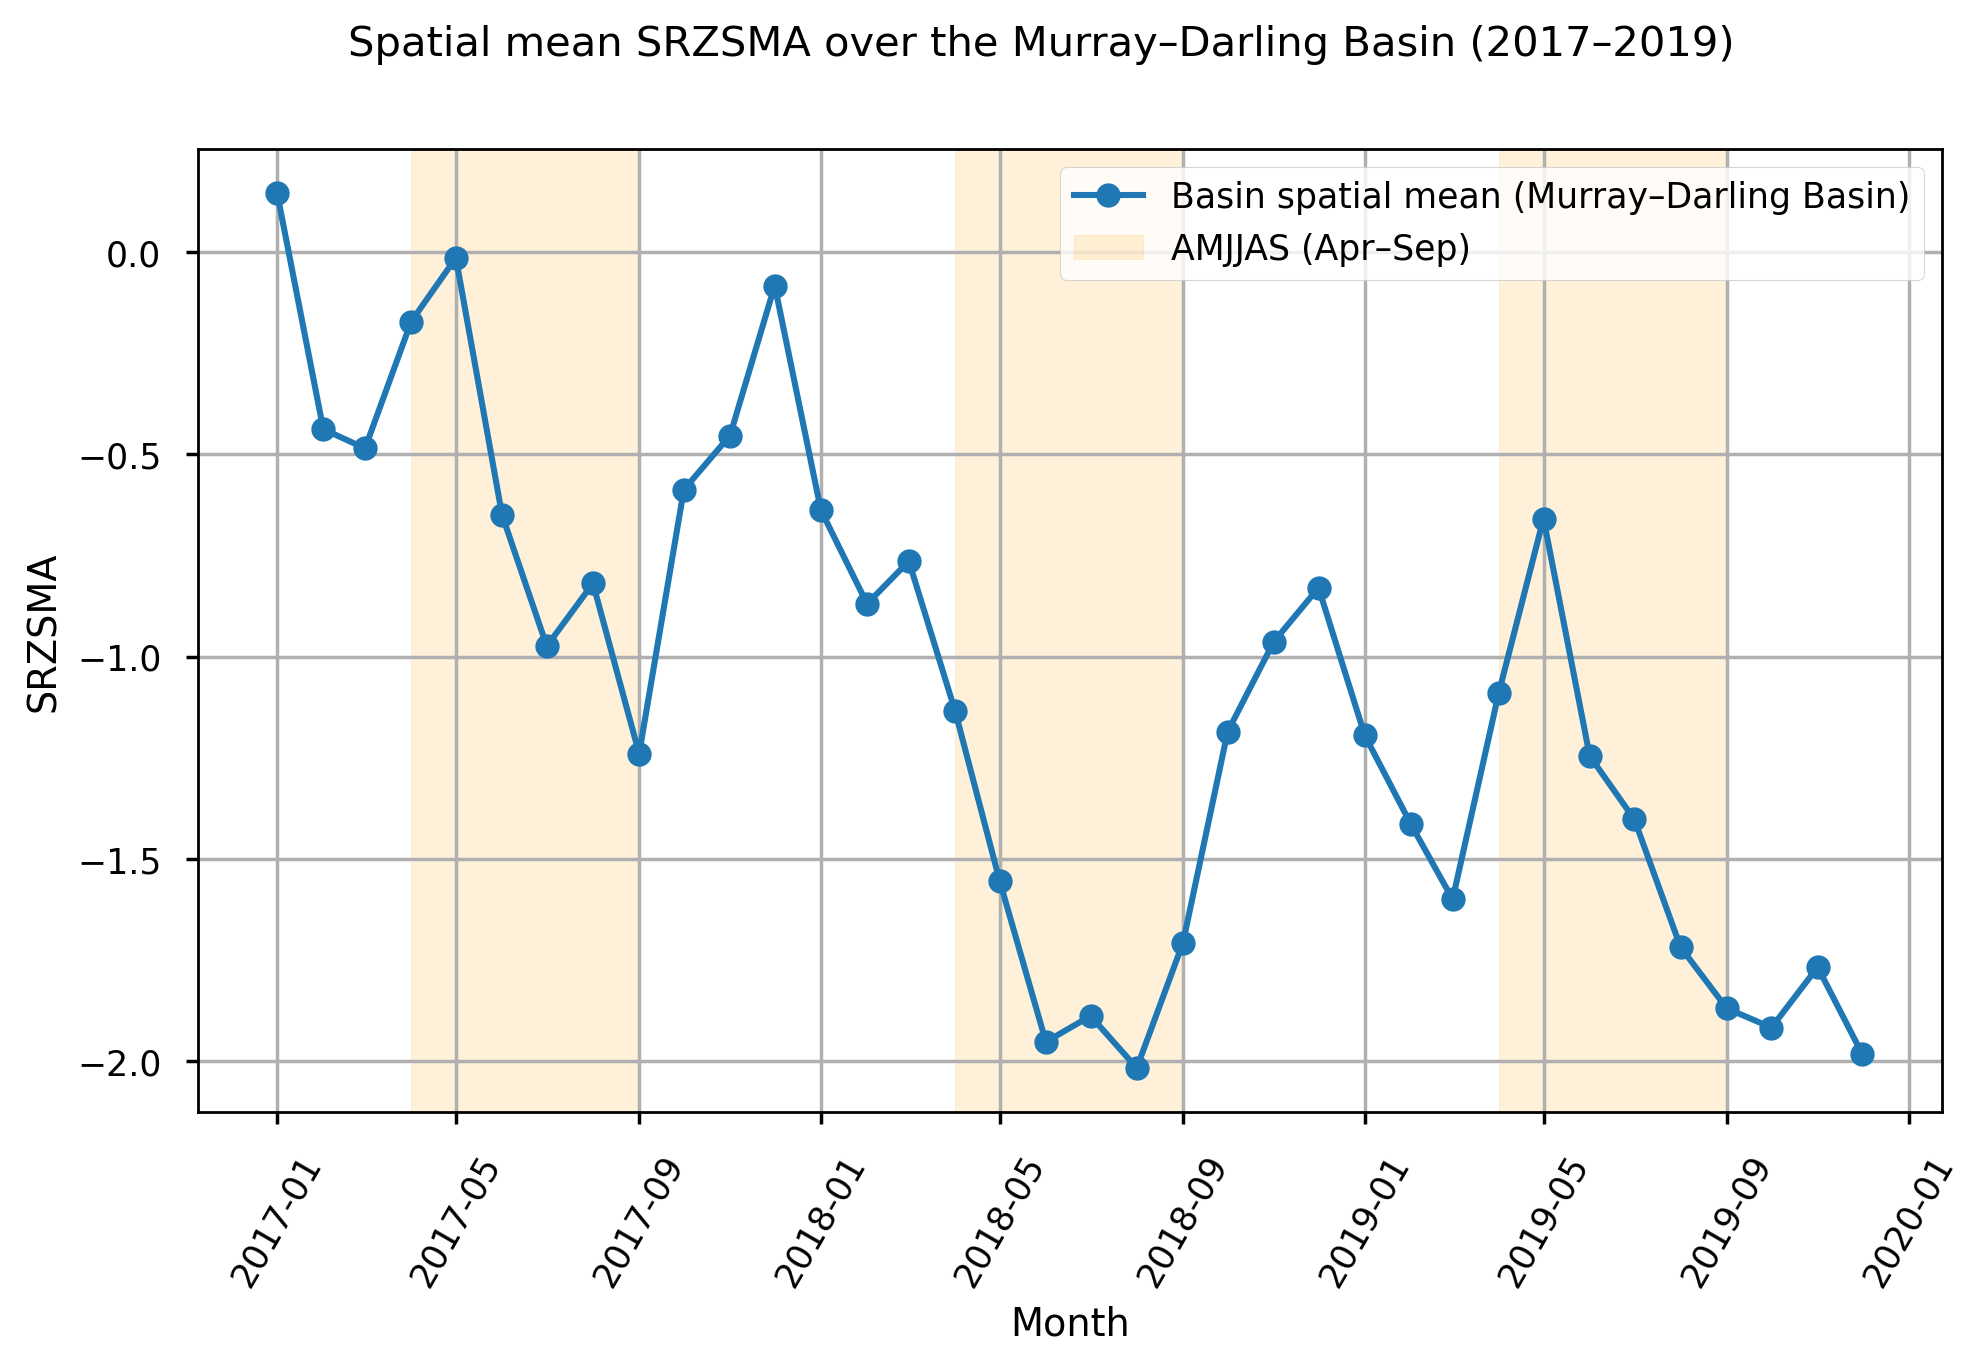

In [93]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=250)

time = pd.to_datetime(ssma_spatial_mean["time"].values)

# Plot line with label
ax.plot(
    time,
    ssma_spatial_mean.values,
    marker="o",
    label="Basin spatial mean (Murray–Darling Basin)"
)

# Highlight AMJJAS (Apr–Sep)
first = True
for year in sorted(set(time.year)):
    start = pd.Timestamp(year=year, month=4, day=1)
    end = pd.Timestamp(year=year, month=9, day=1)

    ax.axvspan(
        start,
        end,
        color="orange",
        alpha=0.15,
        zorder=0,
        label="AMJJAS (Apr–Sep)" if first else None
    )
    first = False

ax.set_ylabel("SRZSMA")
ax.set_xlabel("Month")
ax.grid(True)
ax.tick_params(axis="x", rotation=60)

# Title (clarify basin)
fig.suptitle(
    "Spatial mean SRZSMA over the Murray–Darling Basin (2017–2019)"
)

# Legend
ax.legend()

plt.show()

*Figure 2. Spatially weighted basin-mean SRZSMA for the Murray–Darling Basin (2017–2019). Shaded areas indicate the April–September (AMJJAS) period.*

Figure 2 shows that, with the exception of April and May 2017—when basin-mean SRZSMA values were closer to zero—all cool-season months (April–September) during 2017–2019 exhibit negative anomalies.

The magnitude of these anomalies generally increases over time. In 2017, SRZSMA values from June to September range approximately between −0.5 and −1.5, indicating moderate deficits. In 2018, conditions are more persistently dry, with May slightly below -1.5 and subsequent months falling to almost −2, suggesting more severe anomalies.

In 2019, greater variability is observed at the start of the cool season (e.g., May is closer to −0.6), but conditions intensify again later, with August and September returning to values close to −2. Overall, the time series indicates sustained negative anomalies across the three-year period, with periods of intensified drought conditions.

(satellite_satellite-soil-moisture_extremes-detection_q01:section-4)=
### 4. Fraction of Murray–Darling Basin area below SRZSMA thresholds

To quantify the spatial extent of drought conditions, the fraction of the Murray–Darling Basin area affected by negative anomalies was computed for each time step. For a given SRZSMA threshold (−1, −1.5, −2), grid cells with SRZSMA values below the threshold are identified and assigned a value of 1, while all other cells are assigned 0. A spatially weighted mean of this binary field is then calculated, yielding the proportion of basin area experiencing drought conditions.

This metric complements the basin-mean SRZSMA time series by providing information on how widespread drought conditions are, rather than only their average intensity. It allows assessment of whether dry anomalies are localized or affect large portions of the basin, thereby supporting the evaluation of the dataset’s ability to represent the spatial extent and severity of drought extremes.

In [94]:
def compute_area_fraction_below_threshold(ssma_da, threshold):
    """
    Compute the fraction of basin area with SSMA <= threshold.

    Parameters
    ----------
    ssma_da : xarray.DataArray
        SSMA DataArray already clipped to the basin.
    threshold : float
        Threshold to test, e.g. -1, -1.5, -2.

    Returns
    -------
    xarray.DataArray
        Time series of fraction of basin area below threshold (0 to 1).
    """
    # 1 where drought condition is met, 0 otherwise
    mask = xr.where(ssma_da <= threshold, 1.0, 0.0)

    # keep NaNs where original data are NaN
    mask = mask.where(np.isfinite(ssma_da))

    # weighted spatial mean of 0/1 field = area fraction
    frac = diagnostics.spatial_weighted_mean(mask)

    frac.name = f"area_fraction_below_{threshold}"
    return frac

In [95]:
def plot_area_fraction_below_thresholds(
    ssma_da,
    thresholds,
    title="Fraction of Murray–Darling Basin area below SRZSMA thresholds",
    ylabel="Fraction of basin area",
):
    plt.figure(figsize=(10, 5))

    for th in thresholds:
        frac = compute_area_fraction_below_threshold(ssma_da, th)
        plt.plot(frac.time, frac, label=f"SRZSMA ≤ {th}")

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

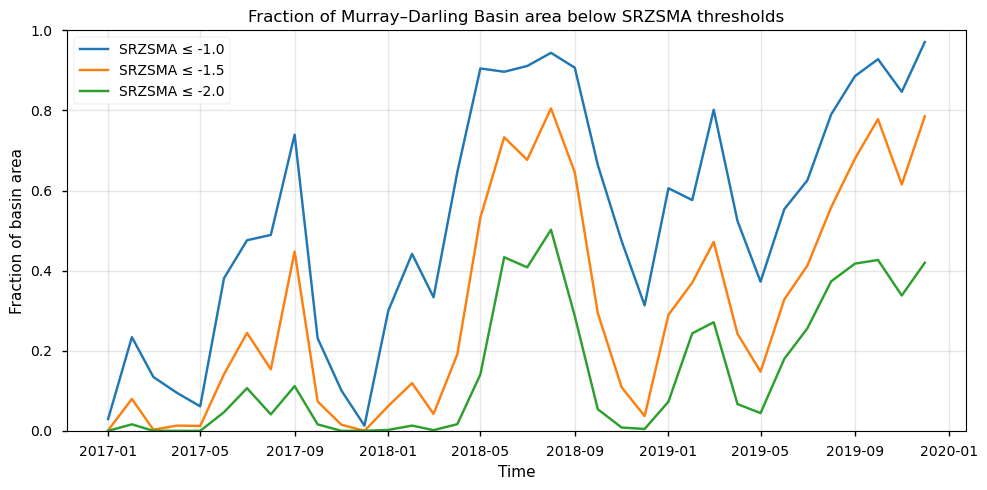

In [96]:
plot_area_fraction_below_thresholds(
    ssma_mdb_2017_2019,
    thresholds=[-1.0, -1.5, -2.0]
)

*Figure 3. Fraction of Murray–Darling Basin area below SRZSMA thresholds (−1, −1.5, −2) during 2017–2019.*

The spatial extent of drought conditions, expressed as the fraction of the Murray–Darling Basin area below SRZSMA thresholds, shows a clear seasonal evolution in 2017 and 2019. In these years, drought conditions are less widespread at the beginning of the cool season (April–May) and expand progressively towards the later months (August–September).

In contrast, 2018 exhibits more persistently widespread conditions throughout the cool season. From May to September, more than 50% of the basin is affected by severe anomalies (SRZSMA ≤ −1.5), while over 90% of the basin experiences moderate anomalies (SRZSMA ≤ −1). This indicates a sustained and spatially extensive drought signal during that year.

#### Maps of SRZSMA

To complement the basin-averaged and spatial extent analyses, spatial patterns of standardized root zone soil moisture anomalies (SRZSMA) are examined for selected months representative of the early and late stages of the cool season. Specifically, maps for May (early season) and September (late season) are shown for the years 2017–2019.

This comparison allows assessment of how drought conditions develop and intensify spatially within each year, and whether the dataset captures the transition from localized anomalies at the start of the season to more widespread and severe conditions towards the end. By selecting consistent months across years, the temporal evolution of drought conditions can be evaluated in a spatially explicit manner.

In [97]:
def add_north_arrow(ax, x=0.93, y=0.92, arrow_length=0.08, fontsize=11):
    """
    Add a simple north arrow in axes coordinates.
    """
    ax.annotate(
        "N",
        xy=(x, y),
        xytext=(x, y - arrow_length),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold",
        arrowprops=dict(facecolor="black", width=2, headwidth=8, headlength=8),
    )


def add_scalebar_lonlat(ax, length_km=200, location=(0.08, 0.07), linewidth=2, fontsize=9):
    """
    Add an approximate scale bar for lon/lat maps in EPSG:4326.

    The conversion uses the mean latitude of the current map extent:
        1 degree longitude ~= 111.32 * cos(latitude) km
    This is acceptable for regional plotting.
    """
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    lat0 = 0.5 * (ymin + ymax)
    km_per_deg_lon = 111.32 * np.cos(np.deg2rad(lat0))

    if km_per_deg_lon <= 0:
        return

    length_deg = length_km / km_per_deg_lon

    x0 = xmin + location[0] * (xmax - xmin)
    y0 = ymin + location[1] * (ymax - ymin)
    x1 = x0 + length_deg

    ax.plot([x0, x1], [y0, y0], color="black", linewidth=linewidth, solid_capstyle="butt")
    ax.plot([x0, x0], [y0 - 0.15, y0 + 0.15], color="black", linewidth=linewidth * 0.8)
    ax.plot([x1, x1], [y0 - 0.15, y0 + 0.15], color="black", linewidth=linewidth * 0.8)

    ax.text(
        (x0 + x1) / 2,
        y0 + 0.35,
        f"{length_km} km",
        ha="center",
        va="bottom",
        fontsize=fontsize,
    )

In [86]:
def plot_ssma_three_dates(
    ssma_da,
    gdf_land,
    dates,                    # e.g. [(2017, 6), (2018, 9), (2019, 9)]
    region_name="Region",
    labels=None,              # optional custom panel titles
    vmin=None,
    vmax=None,
    gdf_basin=None,
    sea_color="#dfeef7",
    land_color="#f2efe9",
    land_edge_color="black",
    land_edge_width=0.5,
    basin_edge_color="black",
    basin_edge_width=0.9,
    grid_color="0.8",
    grid_linewidth=0.5,
    scalebar_km=200,
    cmap="BrBG",
):
    """
    Plot one SSMA dataset for three selected dates in a 1x3 panel layout.

    Parameters
    ----------
    ssma_da : xarray.DataArray
        DataArray with dimensions including time, latitude, longitude.
    gdf_land : GeoDataFrame
        Land polygon to fill, e.g. Australia outline.
    dates : list of tuple
        List like [(year1, month1), (year2, month2), (year3, month3)].
    region_name : str
        Region name to include in titles.
    labels : list of str, optional
        Custom titles for each panel. Must have same length as dates.
    vmin, vmax : float, optional
        Color scale limits. If omitted, symmetric limits are computed from all maps.
    gdf_basin : GeoDataFrame, optional
        Basin outline to overlay.
    """

    if len(dates) != 3:
        raise ValueError("dates must contain exactly 3 (year, month) tuples.")

    time_strs = [f"{year}-{month:02d}-01" for year, month in dates]
    maps = [ssma_da.sel(time=t).where(np.isfinite(ssma_da.sel(time=t))) for t in time_strs]

    if vmin is None or vmax is None:
        mins = [float(m.min(skipna=True).compute()) for m in maps]
        maxs = [float(m.max(skipna=True).compute()) for m in maps]
        absmax = max(max(abs(v) for v in mins), max(abs(v) for v in maxs))
        vmin, vmax = -absmax, absmax

    maps = [m.compute() for m in maps]

    if labels is None:
        labels = [f"{year}-{month:02d}" for year, month in dates]

    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 5),
        dpi=250,
        sharex=True,
        sharey=True,
        gridspec_kw={"wspace": 0.03}
    )
    
    last_im = None

    for ax, map_da, label in zip(axes, maps, labels):
        ax.set_facecolor(sea_color)

        gdf_land.plot(
            ax=ax,
            color=land_color,
            edgecolor=land_edge_color,
            linewidth=land_edge_width,
            zorder=1,
        )

        last_im = map_da.plot(
            ax=ax,
            x="longitude",
            y="latitude",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False,
            zorder=2,
        )

        if gdf_basin is not None:
            gdf_basin.boundary.plot(
                ax=ax,
                color=basin_edge_color,
                linewidth=basin_edge_width,
                zorder=3,
            )

        gdf_land.boundary.plot(
            ax=ax,
            color=land_edge_color,
            linewidth=land_edge_width,
            zorder=4,
        )

        ax.set_xlim(137, 155)
        ax.set_ylim(-40, -23)
        ax.grid(True, color=grid_color, linewidth=grid_linewidth, alpha=0.7)

        add_north_arrow(ax)
        add_scalebar_lonlat(ax, length_km=scalebar_km)

        ax.set_title(f"{label}\n{region_name}", fontsize=10)
        ax.set_xlabel("Longitude")

    axes[0].set_ylabel("Latitude")
    axes[1].set_ylabel("")
    axes[2].set_ylabel("")

    cbar = fig.colorbar(
        last_im,
        ax=axes,
        orientation="horizontal",
        fraction=0.04,
        pad=0.15
    )
    cbar.set_label("SRZSMA")

    plt.show()

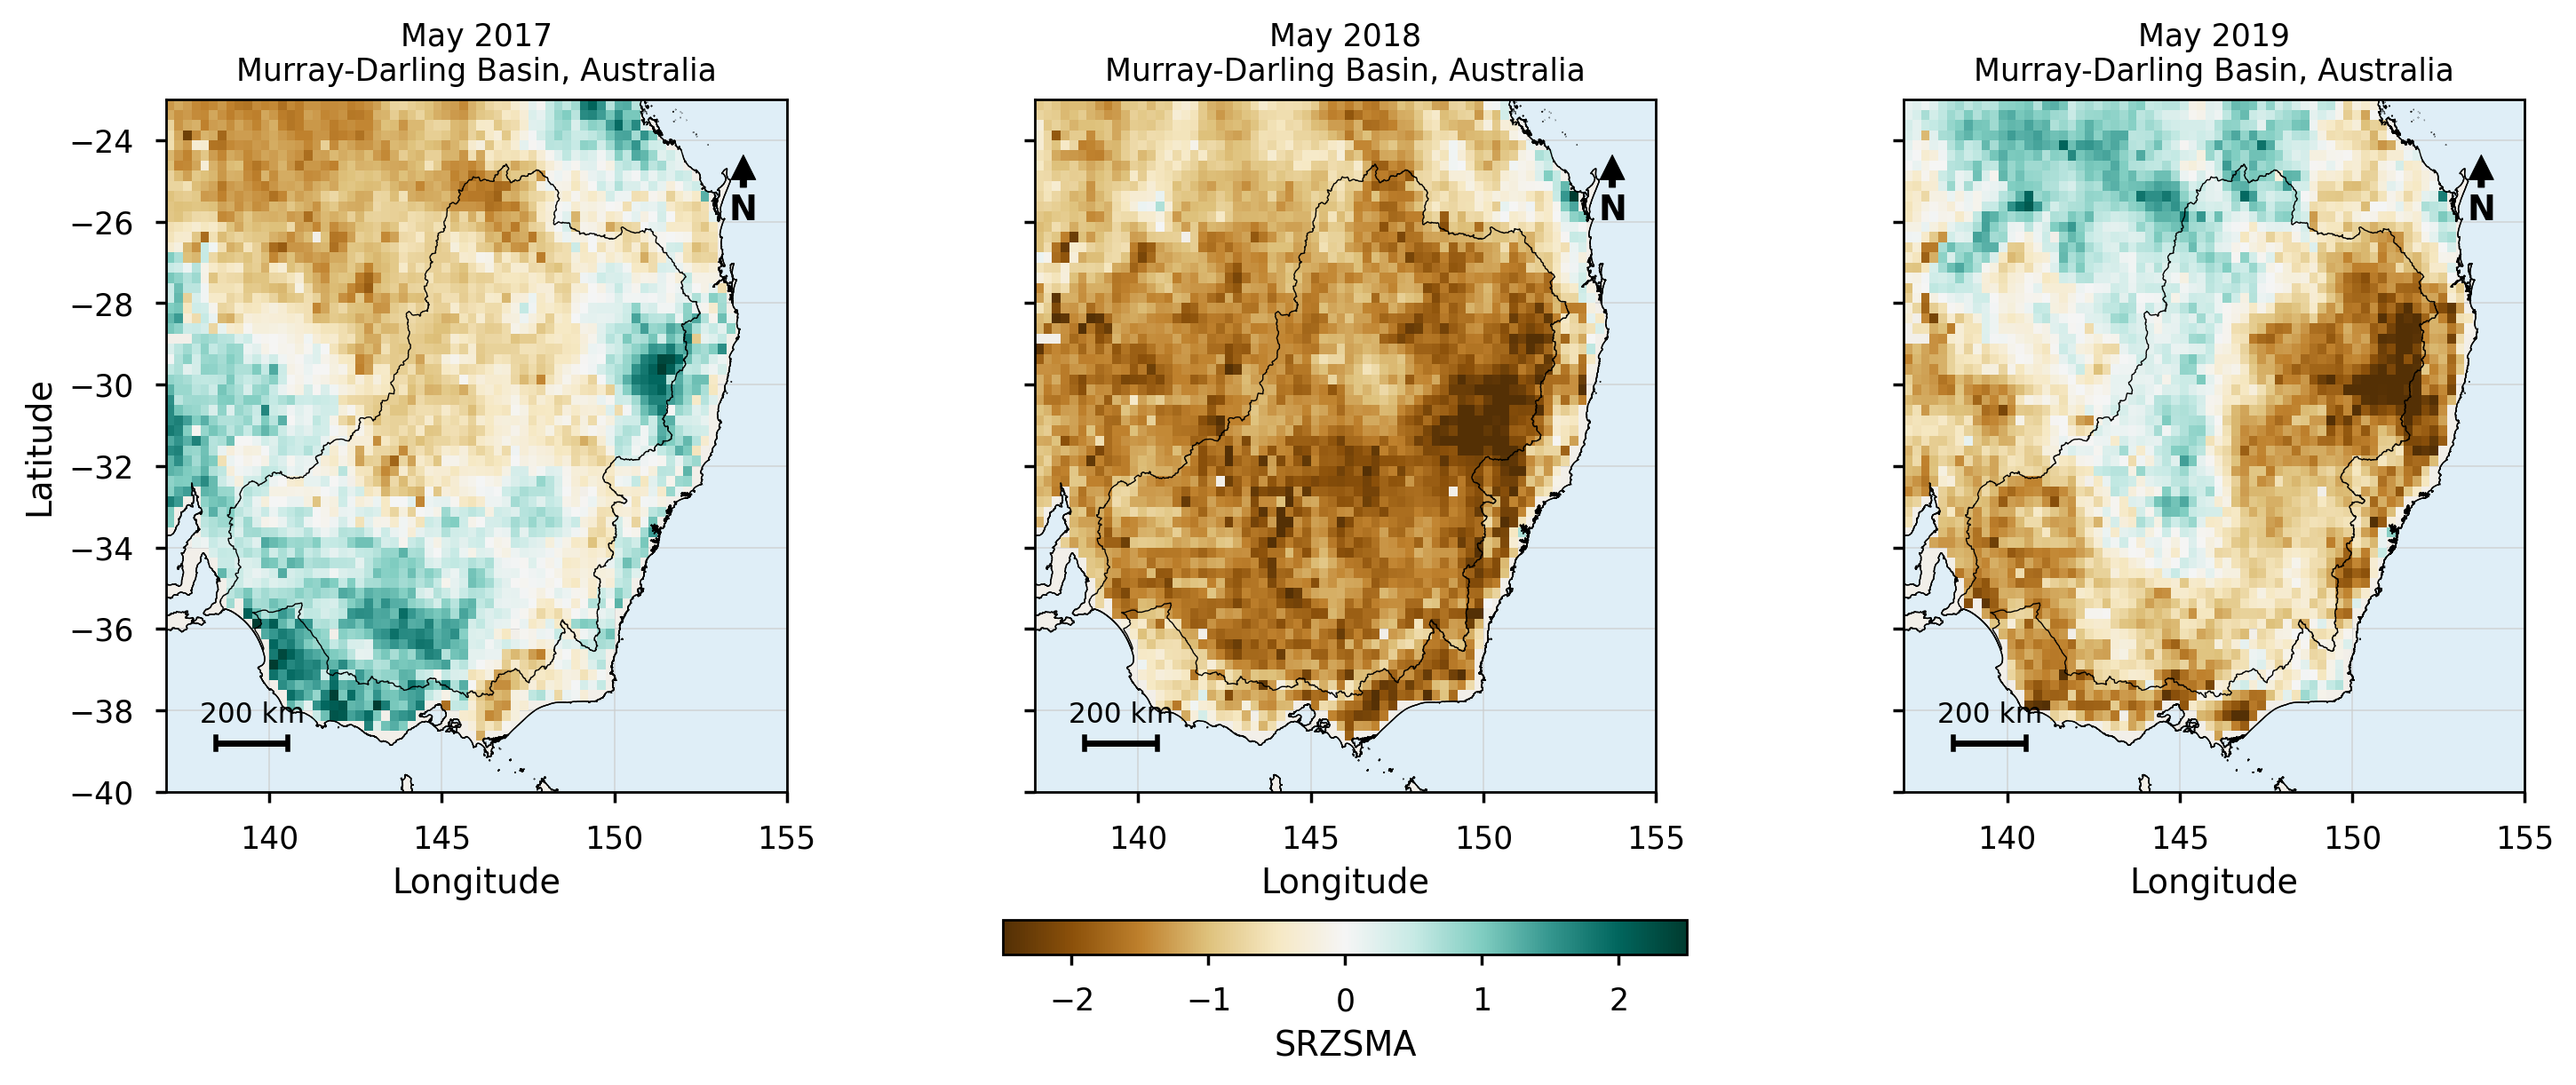

In [98]:
plot_ssma_three_dates(
    ssma_da=ssma_aus,
    gdf_land=aus,
    dates=[(2017, 5), (2018, 5), (2019, 5)],                   
    region_name="Murray-Darling Basin, Australia",
    labels=["May 2017", "May 2018", "May 2019"],  
    vmin=-2.5,
    vmax=2.5,
    gdf_basin=mdb_gdf,
    sea_color="#dfeef7",
    land_color="#f2efe9",
    land_edge_color="black",
    land_edge_width=0.4,
    basin_edge_color="black",
    basin_edge_width=0.4,
    grid_color="0.8",
    grid_linewidth=0.5,
    scalebar_km=200,
    cmap="BrBG"
)

*Figure 4. Spatial distribution of SRZSMA over the Murray–Darling Basin for May 2017–2019, representing early cool-season conditions.*

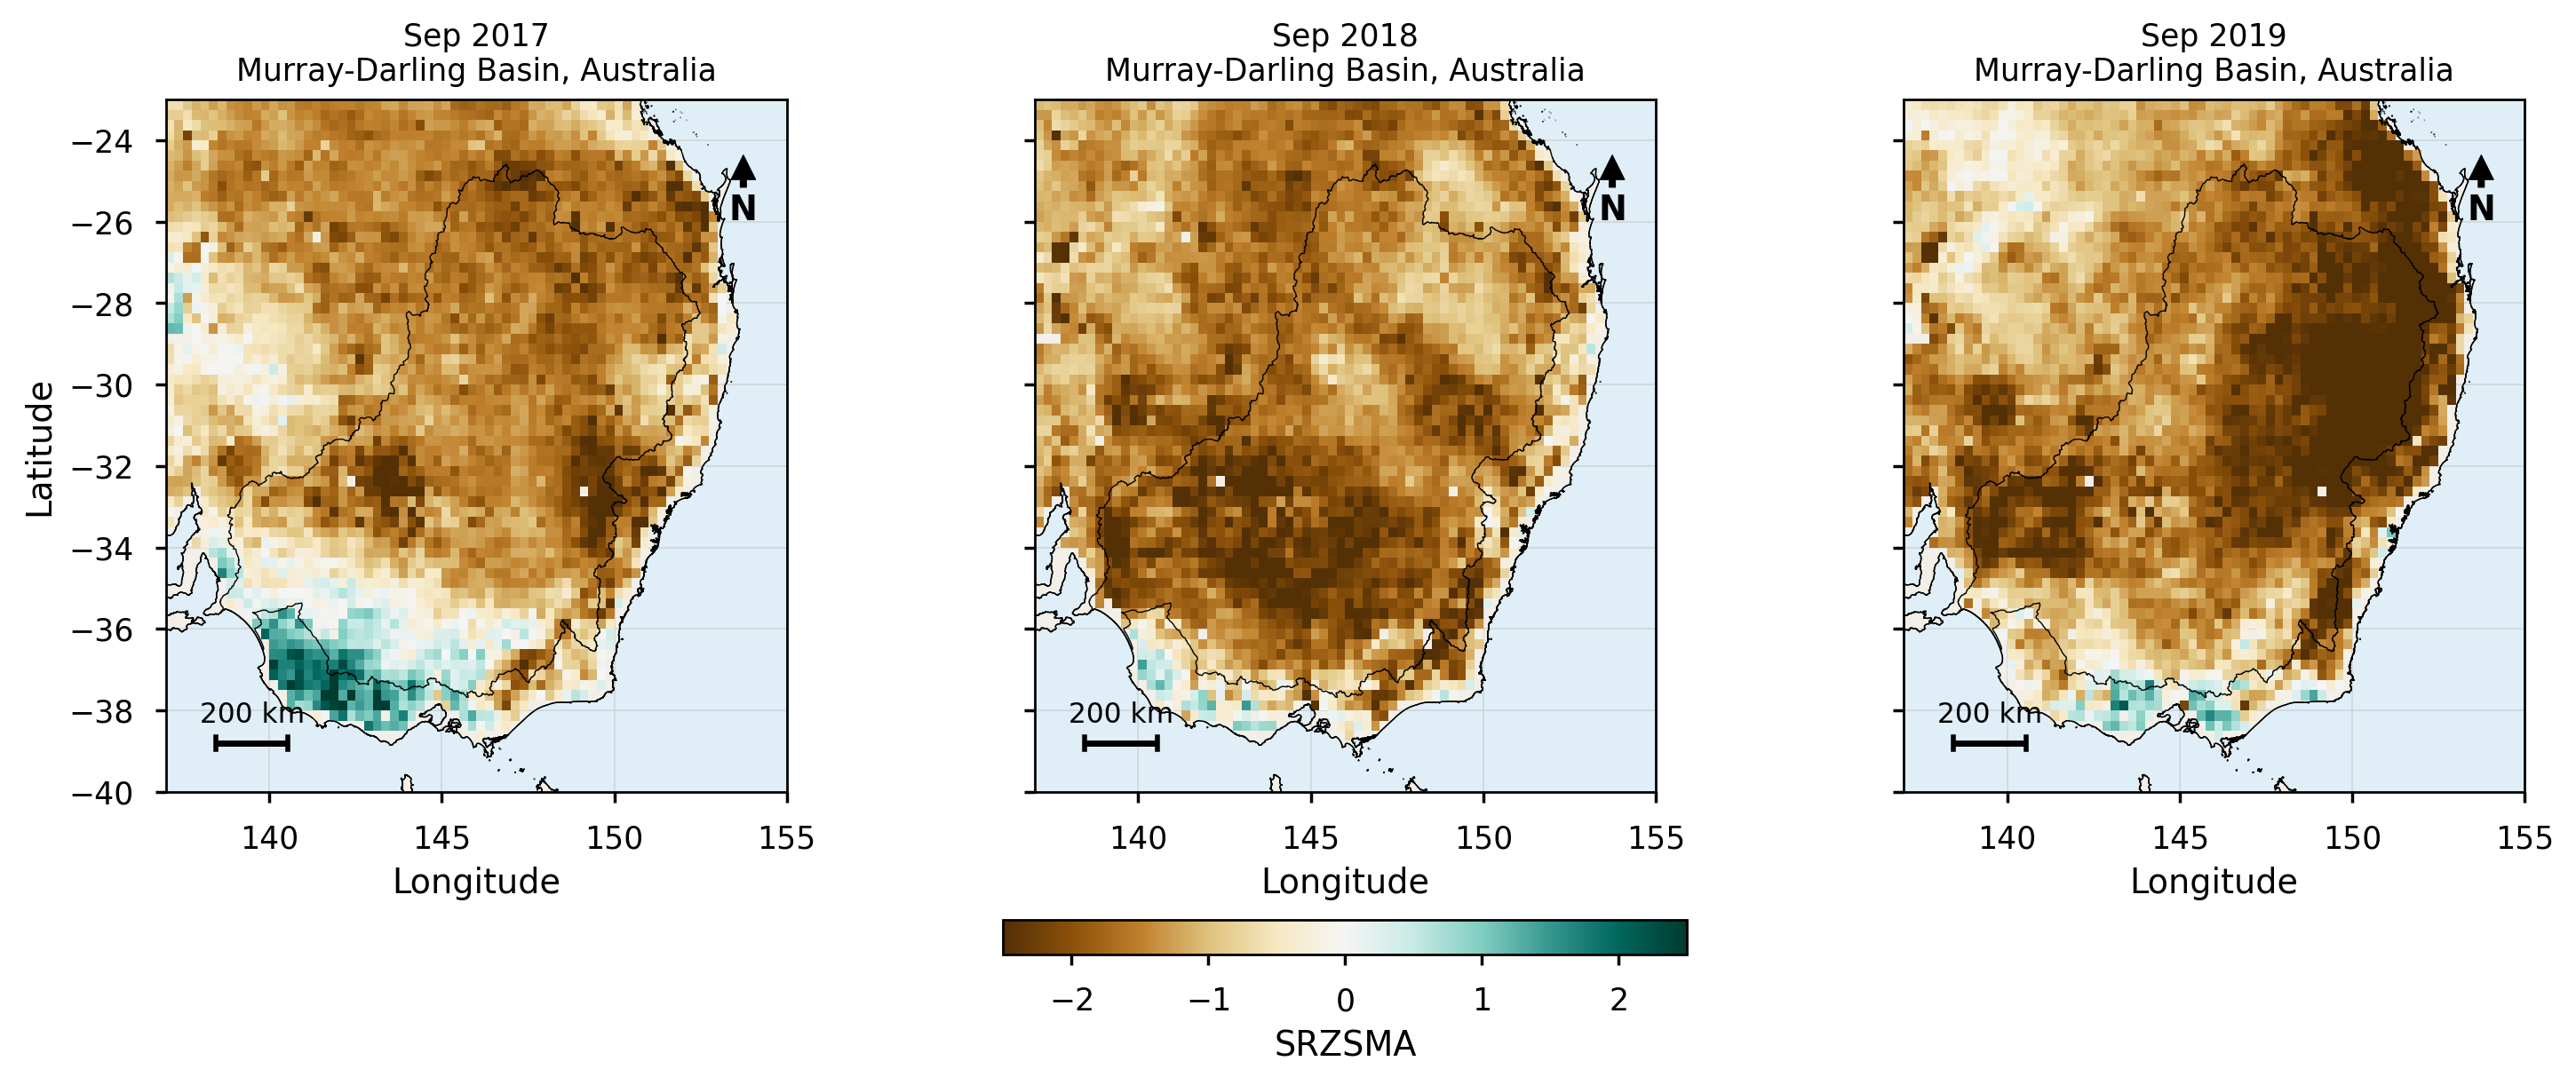

In [99]:
plot_ssma_three_dates(
    ssma_da=ssma_aus,
    gdf_land=aus,
    dates=[(2017, 9), (2018, 9), (2019, 9)],                   
    region_name="Murray-Darling Basin, Australia",
    labels=["Sep 2017", "Sep 2018", "Sep 2019"],  
    vmin=-2.5,
    vmax=2.5,
    gdf_basin=mdb_gdf,
    sea_color="#dfeef7",
    land_color="#f2efe9",
    land_edge_color="black",
    land_edge_width=0.4,
    basin_edge_color="black",
    basin_edge_width=0.4,
    grid_color="0.8",
    grid_linewidth=0.5,
    scalebar_km=200,
    cmap="BrBG"
)

*Figure 5. Spatial distribution of SRZSMA over the Murray–Darling Basin for September 2017–2019, representing late cool-season conditions.*

The spatial patterns of SRZSMA in May show notable differences across the three years. In May 2017 and 2019, parts of the basin still exhibit near-normal to positive anomalies, indicating that drought conditions were not yet fully developed. In 2019, however, strongly negative anomalies (SRZSMA < −2) are already present in the north-eastern part of the basin, while the western region shows near-normal to slightly positive conditions. In contrast, May 2018 is characterized by consistently negative anomalies across the entire basin, indicating more uniformly developed drought conditions at the start of the season.

By September, drought conditions are more widespread and intensified in all years. In 2017, some localized positive anomalies persist in the southernmost part of the basin, while the rest of the region exhibits negative values. In both 2018 and 2019, the basin is entirely dominated by negative anomalies. In 2018, the most severe anomalies (SRZSMA < −2) are concentrated in the southern part of the basin, whereas in 2019, the strongest negative anomalies are located in the eastern region. These spatial patterns indicate a progression from more localized anomalies early in the season to widespread and intensified drought conditions by September.

(satellite_satellite-soil-moisture_extremes-detection_q01:section-5)=
### 5. Percentile-based drought frequency

To compare the C3S root zone soil moisture product with the percentile-based drought frequency approach used by Devanand et al. (2024) [[5]](https://doi.org/10.1126/sciadv.adj3460), the fraction of time below low soil moisture thresholds was calculated for each grid cell. First, calendar-month-specific percentile thresholds were derived from the 1980–2016 baseline period. This means that each month is compared only with its own historical distribution, for example April values are compared with the April baseline threshold.

The analysis was then restricted to the April–September cool-season months during 2017–2019. For each grid cell, the number of selected months with root zone soil moisture below the percentile threshold was divided by the total number of valid selected months. The resulting maps show the fraction of cool-season months during which each grid cell experienced unusually low soil moisture conditions. Two thresholds are shown: P15 and P07.

In [101]:
def compute_fraction_months_below_percentile(
    sm_da,
    percentile=0.15,
    baseline_start="1980",
    baseline_end="2016",
    analysis_start="2017",
    analysis_end="2019",
    months=[4, 5, 6, 7, 8, 9],
):
    """
    Compute, for each pixel, the fraction of selected months in the analysis period
    where soil moisture is below the corresponding calendar-month percentile
    threshold from the baseline period.
    """

    # Baseline threshold per calendar month
    sm_baseline = sm_da.sel(time=slice(baseline_start, baseline_end)).chunk({"time": -1})

    threshold = (
        sm_baseline
        .groupby("time.month")
        .quantile(percentile, dim="time")
    )

    # Analysis period and selected months
    sm_analysis = sm_da.sel(time=slice(analysis_start, analysis_end))

    sm_selected = sm_analysis.sel(
        time=sm_analysis.time.dt.month.isin(months)
    )

    # Compare each month with its corresponding monthly threshold
    below = sm_selected.groupby("time.month") <= threshold

    # Preserve missing data
    below = below.where(np.isfinite(sm_selected))

    # Fraction of selected months below threshold
    frac = below.sum(dim="time") / below.count(dim="time")

    frac.name = f"fraction_months_below_p{int(percentile * 100)}"

    return frac

In [102]:
def plot_two_fraction_maps(
    map1,
    map2,
    gdf_land,
    gdf_basin=None,
    title1="SM ≤ P15",
    title2="SM ≤ P05",
    region_name="Murray-Darling Basin, Australia",
    sea_color="#dfeef7",
    land_color="#f2efe9",
    land_edge_color="black",
    land_edge_width=0.5,
    basin_edge_color="black",
    basin_edge_width=0.9,
    grid_color="0.8",
    grid_linewidth=0.5,
    scalebar_km=200,
    cmap="YlOrBr",
    bounds=[0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    cbar_ticks=[0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    cbar_label="Fraction of AMJJAS months",
    xlim=(137, 155),
    ylim=(-40, -23),
):
    map1 = map1.compute() if hasattr(map1, "compute") else map1
    map2 = map2.compute() if hasattr(map2, "compute") else map2

    cmap_obj = plt.get_cmap(cmap, len(bounds) - 1).copy()
    cmap_obj.set_bad(color="none")
    norm = BoundaryNorm(bounds, cmap_obj.N)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=250)
    fig.subplots_adjust(wspace=0.05)

    ims = []

    for ax, da, title in zip(axes, [map1, map2], [title1, title2]):
        ax.set_facecolor(sea_color)

        gdf_land.plot(
            ax=ax,
            color=land_color,
            edgecolor=land_edge_color,
            linewidth=land_edge_width,
            zorder=1,
        )

        im = da.plot(
            ax=ax,
            x="longitude",
            y="latitude",
            cmap=cmap_obj,
            norm=norm,
            add_colorbar=False,
            zorder=2,
        )

        ims.append(im)

        if gdf_basin is not None:
            gdf_basin.boundary.plot(
                ax=ax,
                color=basin_edge_color,
                linewidth=basin_edge_width,
                zorder=3,
            )

        gdf_land.boundary.plot(
            ax=ax,
            color=land_edge_color,
            linewidth=land_edge_width,
            zorder=4,
        )

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.grid(True, color=grid_color, linewidth=grid_linewidth, alpha=0.7)

        add_north_arrow(ax)
        add_scalebar_lonlat(ax, length_km=scalebar_km)

        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    cbar = fig.colorbar(
        ims[0],
        ax=axes,
        orientation="horizontal",
        fraction=0.05,
        pad=0.12,
    )
    cbar.set_label(cbar_label)
    cbar.set_ticks(cbar_ticks)

    fig.suptitle(region_name, fontsize=11)

    plt.show()

In [103]:
frac_p15_rz = compute_fraction_months_below_percentile(
    sm_aus,
    percentile=0.15,
    baseline_start="1980",
    baseline_end="2016",
    analysis_start="2017",
    analysis_end="2019",
    months=[4, 5, 6, 7, 8, 9],
)

frac_p07_rz = compute_fraction_months_below_percentile(
    sm_aus,
    percentile=0.07,
    baseline_start="1980",
    baseline_end="2016",
    analysis_start="2017",
    analysis_end="2019",
    months=[4, 5, 6, 7, 8, 9],
)

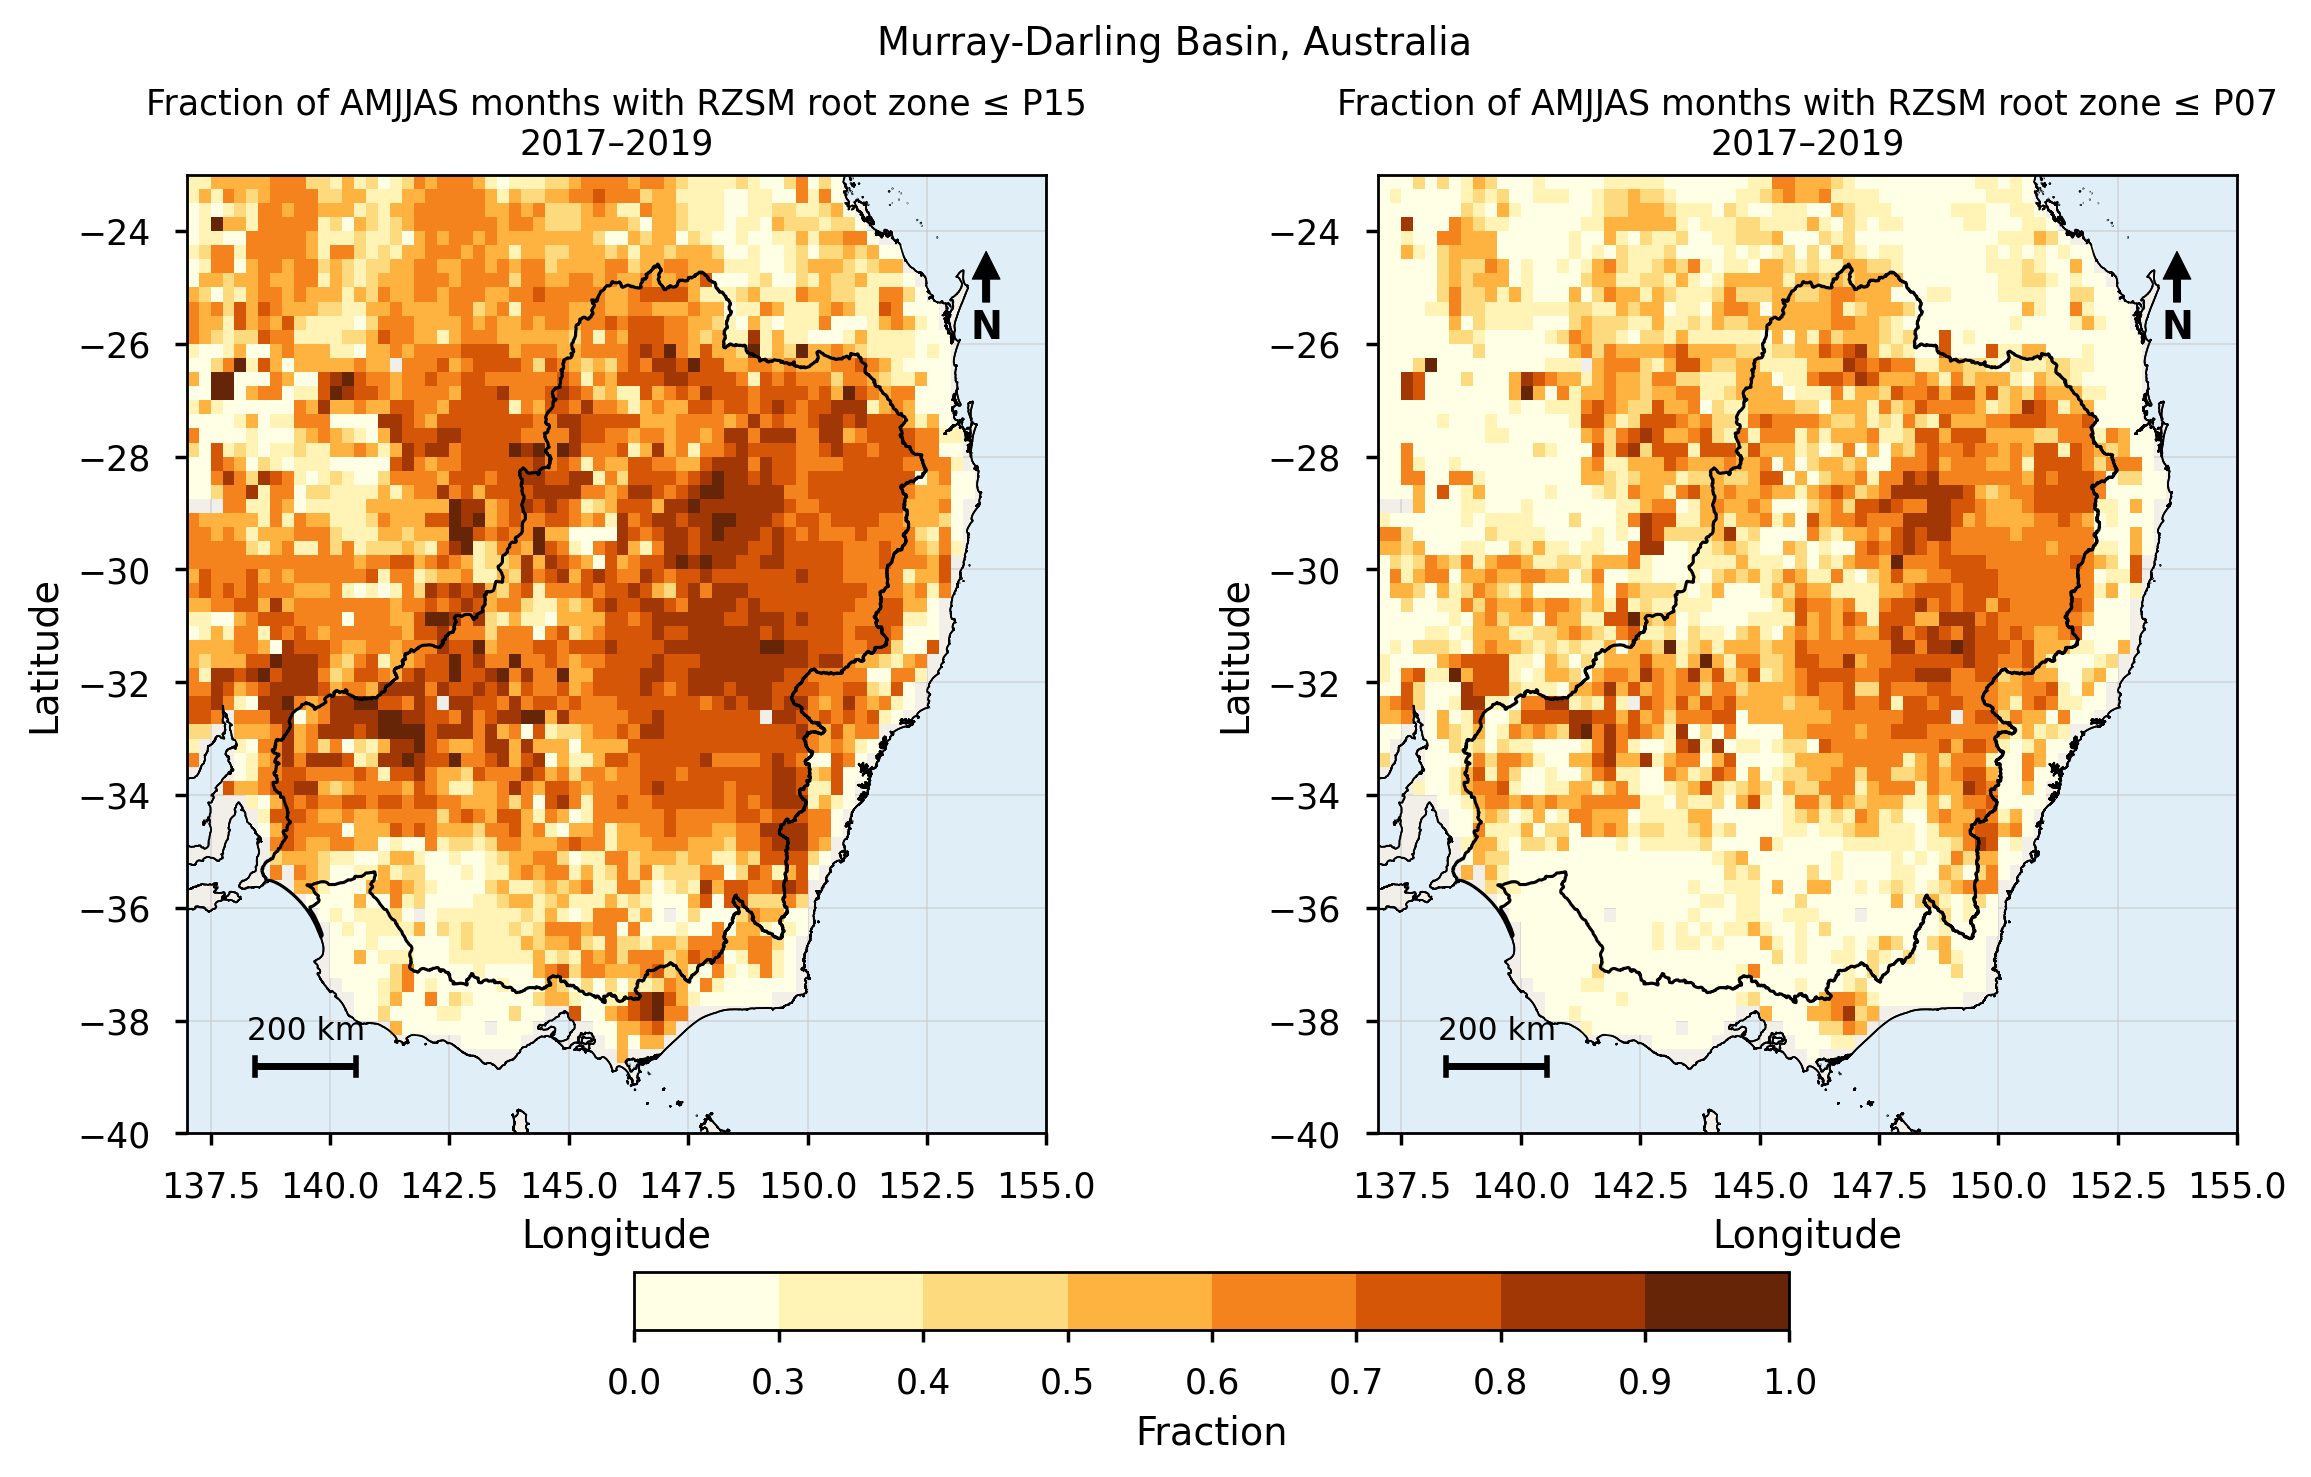

In [104]:
plot_two_fraction_maps(
    map1=frac_p15_rz,
    map2=frac_p07_rz,
    gdf_land=aus,
    gdf_basin=mdb_gdf,
    title1="Fraction of AMJJAS months with RZSM root zone ≤ P15\n2017–2019",
    title2="Fraction of AMJJAS months with RZSM root zone ≤ P07\n2017–2019",
    region_name="Murray-Darling Basin, Australia",
    cbar_label="Fraction",
)

*Figure 6. Fraction of April–September months during 2017–2019 with root zone soil moisture below the calendar-month-specific P15 and P07 thresholds derived from the 1980–2016 baseline.*

![image.png](e49a624c-e806-4b77-bfce-c586efec4f30.png)

*Figure 7. The proportion of time in drought based on various metrics and the focus region for analysis. (A-B) the mean proportion of time SPI-3/SPEI-3 ≤ -1 during JJAS 2017-19 and all months 2017-19 based on three precipitation and two PET datasets, (C-D) the mean proportion of time during which the AMJJAS total and annual precipitation are below the corresponding 15th percentile thresholds based on three precipitation datasets, and (E-F) the mean proportion of time during which the AMJJAS and annual mean root zone soil moisture (rzsm) from the two land surface datasets are below the corresponding 15th percentile thresholds. A reference period of 1980-01 to 2016-12 is used to calculate SPI-3/SPEI-3 and the percentile thresholds. Thick black line on each panel shows the drought area. Source: Devanand et al. (2024) Fig. S1 [[5]](https://doi.org/10.1126/sciadv.adj3460).*

In the study by Devanand et al. (2024), the spatial extent of the Tinderbox Drought is not defined from a single dataset or indicator, but from the consistent spatial patterns of drought persistence across multiple metrics. In particular, the authors compute the fraction of time in drought during the cool season (April–September, 2017–2019) using standardized indices such as SPI-3 and SPEI-3, and complement this analysis with additional indicators, including root zone soil moisture, shown here in Figure 7. The final drought focus region is delineated based on the agreement between these different variables.

When applying the same percentile-based approach to the C3S root zone soil moisture dataset, the P15 threshold produces more spatially uniform patterns, with large surrounding areas also exhibiting low values. As a result, the spatial outline of the drought-affected region is less clearly distinguishable.

To better isolate the core areas of most severe dryness, a lower percentile threshold (7th percentile) was also examined. At this more restrictive threshold, the spatial patterns show more localized clusters of low soil moisture, which are more comparable to those observed in Figure S1 (E) of Devanand et al. (2024). In particular, surrounding regions tend to exhibit higher values, while the most affected areas form more distinct clusters.

Differences in the spatial patterns between the C3S and GLEAM datasets can be explained by the distinct methodologies used to derive root zone soil moisture. According to the supplementary material, Devanand et al. (2024) use the GLEAM root zone soil moisture product. The Global Land Evaporation Amsterdam Model (GLEAM) is designed to maximise the use of satellite-derived observations to produce spatially consistent estimates of terrestrial evaporative flux. In GLEAM, root zone soil moisture is simulated using a daily water balance model and then updated through a Kalman filter that assimilates satellite surface soil moisture observations, weighting them according to their uncertainty. [[6]](https://doi.org/10.5194/hess-15-453-2011). In contrast, in the C3S dataset, root zone soil moisture is derived from surface soil moisture by applying an exponential filtering (infiltration) model that smooths and temporally delays the surface signal using a calibrated memory parameter (T), and then combines multiple depth layers into a weighted average representing the 0–1 m soil profile (see [ATBD](https://confluence.ecmwf.int/pages/viewpage.action?pageId=514318064)).


The C3S product is based on a filtering approach applied to surface soil moisture, resulting in higher spatial variability and less coherent patterns, while GLEAM uses a process-based water balance model with data assimilation, producing smoother and more spatially consistent fields.

As a result, percentile-based thresholds behave differently across datasets. In the C3S dataset, the P15 threshold identifies broadly dry conditions across large areas, making the drought-affected region less clearly defined. A lower percentile (e.g. P07) is required to isolate the core areas of most severe anomalies. This does not indicate that the drought is more intense in C3S, but rather reflects differences in the variability and distribution of soil moisture, which affect how percentile thresholds delineate extreme conditions.

## ℹ️ If you want to know more

* O, S., Hou, X. & Orth, R. Observational evidence of wildfire-promoting soil moisture anomalies. Sci Rep 10, 11008 (2020). [](https://doi.org/10.1038/s41598-020-67530-4)
* Murray–Darling Basin Authority (2025). Recent significant droughts and floods. [](https://www.mdba.gov.au/science-and-knowledge/sustainable-rivers-audit/2025-insights-and-findings/recent-significant-droughts-and-floods)

### Key resources

Code libraries used:
* [C3S EQC custom functions](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control), `c3s_eqc_automatic_quality_control`,  prepared by [B-Open](https://www.bopen.eu/)

Dataset documentation:

* [SM v202505: Product User Guide and Specification (PUGS)](https://confluence.ecmwf.int/pages/viewpage.action?pageId=514318069)

* [SM v202505: Algorithm Theoretical Basis Document (ATBD)](https://confluence.ecmwf.int/pages/viewpage.action?pageId=514318064)

* [SM v202505: Product Quality Assessment Report (PQAR)](https://confluence.ecmwf.int/pages/viewpage.action?pageId=514318066)

### References

[[1]](https://doi.org/10.1126/sciadv.adj3460) Anjana Devanand et al. (2024). Australia’s Tinderbox Drought: An extreme natural event likely worsened by human-caused climate change. Science Advances Vol 10 Issue 10.

[[2]](https://data.gov.au/data/dataset/4ede9aed-5620-47db-a72b-0b3aa0a3ced0/resource/8a6d889d-723b-492d-8c12-b8b0d1ba4b5a) Murray–Darling Basin Authority (2019). Murray–Darling Basin Boundary – Water Act 2007. Data.gov.au. Accessed 23 April 2026.

[[3]](https://gadm.org/download_country.html) GADM. (2023). GADM database of global administrative areas (version 4.1). Data accessed via UC Davis GeoData repository.

[[4]](https://drought.emergency.copernicus.eu/data/factsheets/factsheet_soilmoisture.pdf) European Commission (2019). EDO INDICATOR FACTSHEET Soil Moisture Anomaly (SMA). European Drought Observatory.

[[5]](https://doi.org/10.1126/sciadv.adj3460) Anjana Devanand et al. (2024). Supplementary Materials for: Australia’s Tinderbox Drought: An extreme natural event likely worsened by human-caused climate change. Science Advances Vol 10 Issue 10.

[[6]](https://doi.org/10.5194/hess-15-453-2011) Miralles, D. G., Holmes, T. R. H., de Jeu, R. A. M., Gash, J. H., Meesters, A. G. C. A., & Dolman, A. J. (2011). Global land-surface evaporation estimated from satellite-based observations. Hydrology and Earth System Sciences, 15, 453–469.